In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

In [3]:
dataset = load_dataset("windchimeran/GMRID")

In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'Headline', 'Details', 'Severity', 'Region', 'Datetime', 'lat', 'lon', 'maritime_label', 'found_ports', 'contains_port_info', 'if_labeled', 'Headline_Details', 'Year', 'Month', 'Week', 'Details_cleaned', 'Category', 'Summarized_label', 'gpt-4o_label'],
        num_rows: 4594
    })
    test: Dataset({
        features: ['id', 'Headline', 'Details', 'Severity', 'Region', 'Datetime', 'lat', 'lon', 'maritime_label', 'found_ports', 'contains_port_info', 'if_labeled', 'Headline_Details', 'Year', 'Month', 'Week', 'Details_cleaned', 'Category', 'Summarized_label', 'gpt-4o_label'],
        num_rows: 1147
    })
})


In [5]:
print(dataset.keys())

dict_keys(['train', 'test'])


In [6]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [7]:
print(train_df.shape)
print(test_df.shape)
print(train_df.columns.tolist())

(4594, 20)
(1147, 20)
['id', 'Headline', 'Details', 'Severity', 'Region', 'Datetime', 'lat', 'lon', 'maritime_label', 'found_ports', 'contains_port_info', 'if_labeled', 'Headline_Details', 'Year', 'Month', 'Week', 'Details_cleaned', 'Category', 'Summarized_label', 'gpt-4o_label']


In [8]:
train_df.head()

,id,Headline,Details,Severity,Region,Datetime,lat,lon,maritime_label,found_ports,contains_port_info,if_labeled,Headline_Details,Year,Month,Week,Details_cleaned,Category,Summarized_label,gpt-4o_label
0,552,Severe winds caused brief suspension at Port o...,Local sources reported that operations at Pier...,Minor,South Africa,2018-12-28 05:15:00,-29.88386,31.01766,true,['durban'],true,true,Severe winds caused brief suspension at Port o...,2018,12,52,local source reported operation pier 1 2 conta...,Port Disruption,Weather,{}
1,933,"USA, California: Emergency personnel working t...",Information received states that emergency per...,Moderate,United States,2018-11-17 06:25:00,32.821,-117.153,false,['balboa'],true,false,"USA, California: Emergency personnel working t...",2018,11,46,information received state emergency personnel...,"Roadway Closure / Disruption, Non-industrial Fire",Administrative Issue,{}
2,2973,USA: 'Fridays for Future' climate change prote...,Protests against climate change are anticipate...,Minor,United States,2019-11-27 07:00:00,NaN,NaN,false,['new york'],true,false,USA: 'Fridays for Future' climate change prote...,2019,11,48,protest climate change anticipated nationwide ...,Protest / Riot,Worker Strike,{}
3,6,UPDATE - Indonesia: Severe winds damage infras...,Severe winds have downed billboards and trees ...,Moderate,Indonesia,2017-04-19 09:10:00,-6.91264,107.657,false,['jakarta'],true,true,UPDATE - Indonesia: Severe winds damage infras...,2017,4,16,severe wind downed billboard tree bandung wedn...,"Roadway Closure / Disruption, Flooding, Severe...",Weather,{}
4,4537,UPDATE 1 - Refrigerated container import capac...,Updated sources indicate that terminals at the...,Moderate,China,2020-02-03 21:57:00,38.98074,117.746,true,['tianjin'],true,true,UPDATE 1 - Refrigerated container import capac...,2020,2,6,updated source indicate terminal tianjin port ...,"Port Disruption, Cargo Disruption, Port Conges...",Administrative Issue,{}


In [ ]:
# checking missing columns
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4594 entries, 0 to 4593
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  4594 non-null   int64
 1   Headline            4594 non-null   str  
 2   Details             4594 non-null   str  
 3   Severity            4594 non-null   str  
 4   Region              4594 non-null   str  
 5   Datetime            4594 non-null   str  
 6   lat                 3097 non-null   str  
 7   lon                 3097 non-null   str  
 8   maritime_label      4594 non-null   str  
 9   found_ports         4594 non-null   str  
 10  contains_port_info  4594 non-null   str  
 11  if_labeled          4593 non-null   str  
 12  Headline_Details    4593 non-null   str  
 13  Year                4594 non-null   int64
 14  Month               4594 non-null   int64
 15  Week                4594 non-null   int64
 16  Details_cleaned     4594 non-null   str  
 17  Catego

In [ ]:
# unique count for each column
for col in train_df.columns:
    print(col, train_df[col].nunique())

id 4594
Headline 4529
Details 4594
Severity 4
Region 109
Datetime 4559
lat 2737
lon 2725
maritime_label 2
found_ports 507
contains_port_info 1
if_labeled 2
Headline_Details 4593
Year 4
Month 12
Week 53
Details_cleaned 4594
Category 723
Summarized_label 8
gpt-4o_label 1


category columns are severity , maritime_label , contain_port_info , if_labelled , summarized label and gpt-4o_label

In [11]:
train_df["Summarized_label"].value_counts()

Summarized_label
Administrative Issue    1417
Weather                 1390
Worker Strike            736
Accident                 665
Terrorism                322
Human Error               32
Others                    21
Cyber Attack              11
Name: count, dtype: int64

In [12]:
train_df["Category"].value_counts().head(50)

Category
Port Congestion                                                        563
Port Disruption                                                        406
Port Closure                                                           268
Maritime Advisory                                                      227
Maritime Accident                                                      201
Protest / Riot                                                         138
Industrial Fire                                                        104
Weather Advisory                                                       103
Miscellaneous Events                                                    98
Port Strike                                                             95
Miscellaneous Strikes                                                   90
Earthquake                                                              89
Cargo/Warehouse Theft                                                   79
Cargo Disruption

In [13]:
sorted(train_df["Summarized_label"].dropna().unique())

['Accident',
 'Administrative Issue',
 'Cyber Attack',
 'Human Error',
 'Others',
 'Terrorism',
 'Weather',
 'Worker Strike']

In [14]:
sorted(train_df["Category"].dropna().unique())[:100]

['Airline Incident / Crash',
 'Airline Incident / Crash, Flight Delays / Cancellations',
 'Airport Accident / Closure, Aviation Advisory, Explosion',
 'Airport Accident / Closure, Public Safety / Security, Hurricane, Severe Winds, Ground Transportation Advisory, Weather Advisory',
 'Aviation Advisory, Ground Transportation Advisory, Network Disruption, Maritime Advisory, Miscellaneous Events',
 'Aviation Advisory, Ground Transportation Advisory, Public Health Advisory, Maritime Advisory, Regulatory Advisory',
 'Aviation Advisory, Political Info / Event, Ground Transportation Advisory, Network Disruption, Maritime Advisory, Hurricane, Weather Advisory',
 'Aviation Advisory, Political Info / Event, Maritime Advisory, Miscellaneous Events',
 'Aviation Advisory,Ground Transportation Advisory',
 'Barge Accident',
 'Barge Accident,Waterway closure / Disruption',
 'Bomb Detonation / Explosion',
 'Bomb Detonation / Explosion, Hazmat Response',
 'Bomb Detonation / Explosion, Maritime Accident',

# 5. Define Risk Taxonomy

In [15]:
RISK_TAXONOMY = {
    "weather_disruption": {
        "name": "Weather Disruption",
        "description": (
            "Disruption to trade, transport, ports, logistics, or infrastructure "
            "caused by severe weather such as storms, flooding, high winds, "
            "cyclones, or similar weather-related hazards."
        )
    },

    "natural_disaster": {
        "name": "Natural Disaster",
        "description": (
            "Disruption caused by natural disasters such as earthquakes, "
            "tsunamis, volcanic activity, landslides, or other geological hazards."
        )
    },

    "port_operational_disruption": {
        "name": "Port Operational Disruption",
        "description": (
            "Disruption to normal port or cargo operations caused by congestion, "
            "capacity limitations, operational delays, cargo disruption, "
            "or reduced terminal efficiency."
        )
    },

    "port_closure": {
        "name": "Port Closure",
        "description": (
            "Full or partial closure, suspension, or shutdown of a port, terminal, "
            "pier, berth, or related maritime facility."
        )
    },

    "labor_strike_disruption": {
        "name": "Labor / Strike Disruption",
        "description": (
            "Disruption caused by worker strikes, industrial action, labor disputes, "
            "walkouts, or related workforce actions affecting transport or logistics."
        )
    },

    "maritime_security_navigation_disruption": {
        "name": "Maritime Security / Navigation Disruption",
        "description": (
            "Disruption or increased operational risk to maritime transport caused "
            "by piracy, maritime security threats, navigation restrictions, "
            "maritime advisories, or waterway disruption."
        )
    }
}

In [16]:
for risk_id, data in RISK_TAXONOMY.items():
    print(risk_id, "->", data["name"])

weather_disruption -> Weather Disruption
natural_disaster -> Natural Disaster
port_operational_disruption -> Port Operational Disruption
port_closure -> Port Closure
labor_strike_disruption -> Labor / Strike Disruption
maritime_security_navigation_disruption -> Maritime Security / Navigation Disruption


Build ground-truth mapping
For evaluation, you need a target label such as "true_risk" .
We'll derive it from GMRID's Category.

In [17]:
CATEGORY_TO_RISK = {

    # Weather
    "Weather Advisory": "weather_disruption",
    "Flooding": "weather_disruption",
    "Storm": "weather_disruption",
    "Tropical Cyclone / Storm": "weather_disruption",

    # Natural disaster
    "Earthquake": "natural_disaster",

    # Port operations
    "Port Congestion": "port_operational_disruption",
    "Port Disruption": "port_operational_disruption",
    "Cargo Disruption": "port_operational_disruption",

    # Port closure
    "Port Closure": "port_closure",

    # Labor
    "Port Strike": "labor_strike_disruption",
    "Cargo Transportation Strike": "labor_strike_disruption",

    # Maritime security/navigation
    "Maritime Advisory": "maritime_security_navigation_disruption",
    "Piracy": "maritime_security_navigation_disruption",
    "Waterway Closure / Disruption": "maritime_security_navigation_disruption",
}

In [18]:
def map_categories_to_risks(category_text):
    if pd.isna(category_text):
        return []

    categories = [
        category.strip()
        for category in category_text.split(",")
    ]

    mapped_risks = []

    for category in categories:
        if category in CATEGORY_TO_RISK:
            mapped_risks.append(CATEGORY_TO_RISK[category])

    return list(set(mapped_risks))

In [19]:
# apply the function to create "true_risk"
train_df["true_risks"] = train_df["Category"].apply(
    map_categories_to_risks
)

test_df["true_risks"] = test_df["Category"].apply(
    map_categories_to_risks
)

In [20]:
train_df[
    ["Category", "true_risks"]
].head(20)

,Category,true_risks
0,Port Disruption,[port_operational_disruption]
1,"Roadway Closure / Disruption, Non-industrial Fire",[]
2,Protest / Riot,[]
3,"Roadway Closure / Disruption, Flooding, Severe...",[weather_disruption]
4,"Port Disruption, Cargo Disruption, Port Conges...",[port_operational_disruption]
5,Weather Advisory,[weather_disruption]
6,"Protest / Riot, Ground Transportation Advisory",[]
7,"Cargo Disruption, Roadway Closure / Disruption...","[maritime_security_navigation_disruption, port..."
8,"Port Congestion, Cargo Disruption",[port_operational_disruption]
9,Port Congestion,[port_operational_disruption]


In [ ]:
# remove rows where true_risk is empty
train_df["has_target_risk"] = train_df["true_risks"].apply(
    lambda x: len(x) > 0
)

test_df["has_target_risk"] = test_df["true_risks"].apply(
    lambda x: len(x) > 0
)

In [22]:
# dataset covered by risk taxonomy 
print(
    "Train covered:",
    train_df["has_target_risk"].sum(),
    "/",
    len(train_df)
)

print(
    "Test covered:",
    test_df["has_target_risk"].sum(),
    "/",
    len(test_df)
)

Train covered: 2653 / 4594
Test covered: 643 / 1147


In [23]:
# percentage dataset covered by risk taxonomy 
print(
    "Train coverage:",
    round(train_df["has_target_risk"].mean() * 100, 2),
    "%"
)

print(
    "Test coverage:",
    round(test_df["has_target_risk"].mean() * 100, 2),
    "%"
)

Train coverage: 57.75 %
Test coverage: 56.06 %


In [24]:
# Create POC datasets , filter to records that contain at least one of your six risks

train_poc = train_df[
    train_df["has_target_risk"]
].copy()

test_poc = test_df[
    test_df["has_target_risk"]
].copy()

In [25]:
# Reset indices
train_poc.reset_index(drop=True, inplace=True)
test_poc.reset_index(drop=True, inplace=True)

In [26]:
print(train_poc.shape)
print(test_poc.shape)

(2653, 22)
(643, 22)


In [27]:
train_poc.head()

,id,Headline,Details,Severity,Region,Datetime,lat,lon,maritime_label,found_ports,...,Headline_Details,Year,Month,Week,Details_cleaned,Category,Summarized_label,gpt-4o_label,true_risks,has_target_risk
0,552,Severe winds caused brief suspension at Port o...,Local sources reported that operations at Pier...,Minor,South Africa,2018-12-28 05:15:00,-29.88386,31.01766,true,['durban'],...,Severe winds caused brief suspension at Port o...,2018,12,52,local source reported operation pier 1 2 conta...,Port Disruption,Weather,{},[port_operational_disruption],True
1,6,UPDATE - Indonesia: Severe winds damage infras...,Severe winds have downed billboards and trees ...,Moderate,Indonesia,2017-04-19 09:10:00,-6.91264,107.657,false,['jakarta'],...,UPDATE - Indonesia: Severe winds damage infras...,2017,4,16,severe wind downed billboard tree bandung wedn...,"Roadway Closure / Disruption, Flooding, Severe...",Weather,{},[weather_disruption],True
2,4537,UPDATE 1 - Refrigerated container import capac...,Updated sources indicate that terminals at the...,Moderate,China,2020-02-03 21:57:00,38.98074,117.746,true,['tianjin'],...,UPDATE 1 - Refrigerated container import capac...,2020,2,6,updated source indicate terminal tianjin port ...,"Port Disruption, Cargo Disruption, Port Conges...",Administrative Issue,{},[port_operational_disruption],True
3,3771,Marine wind warning issued for Port of Sydney ...,Industry sources indicate that the Bureau of M...,Minor,Australia,2020-05-21 09:25:00,-33.97373,151.2168,false,['sydney'],...,Marine wind warning issued for Port of Sydney ...,2020,5,21,industry source indicate bureau meteorology is...,Weather Advisory,Weather,{},[weather_disruption],True
4,1947,Osaka’s G20 summit likely to impede logistics ...,Japan will host its first ever Group of Twenty...,Moderate,Japan,2019-06-21 15:21:00,34.43214,135.23035,false,"['kobe', 'osaka']",...,Osaka’s G20 summit likely to impede logistics ...,2019,6,25,japan host first ever group twenty g20 summit ...,"Cargo Disruption, Roadway Closure / Disruption...",Administrative Issue,{},"[maritime_security_navigation_disruption, port...",True


### Target Risk Distribution

The POC dataset contains six target risk classes and exhibits natural class imbalance.

`port_operational_disruption` is the most frequent class, while
`natural_disaster` and `labor_strike_disruption` are comparatively rare.

This imbalance is retained because Stage A uses deterministic rule-based
classification rather than a trained statistical classifier.

Class-level precision, recall, and F1-score will be evaluated separately so
that performance on less frequent risks is not hidden by the dominant class.

In [28]:
# checking class distribution for training data
train_label_counts = (
    train_poc["true_risks"]
    .explode()
    .value_counts()
)

train_label_counts

true_risks
port_operational_disruption                1394
maritime_security_navigation_disruption     464
weather_disruption                          378
port_closure                                355
labor_strike_disruption                     145
natural_disaster                             95
Name: count, dtype: int64

In [29]:
# checking class distribution for test data
test_label_counts = (
    test_poc["true_risks"]
    .explode()
    .value_counts()
)

test_label_counts

true_risks
port_operational_disruption                351
maritime_security_navigation_disruption     97
weather_disruption                          87
port_closure                                85
labor_strike_disruption                     39
natural_disaster                            29
Name: count, dtype: int64

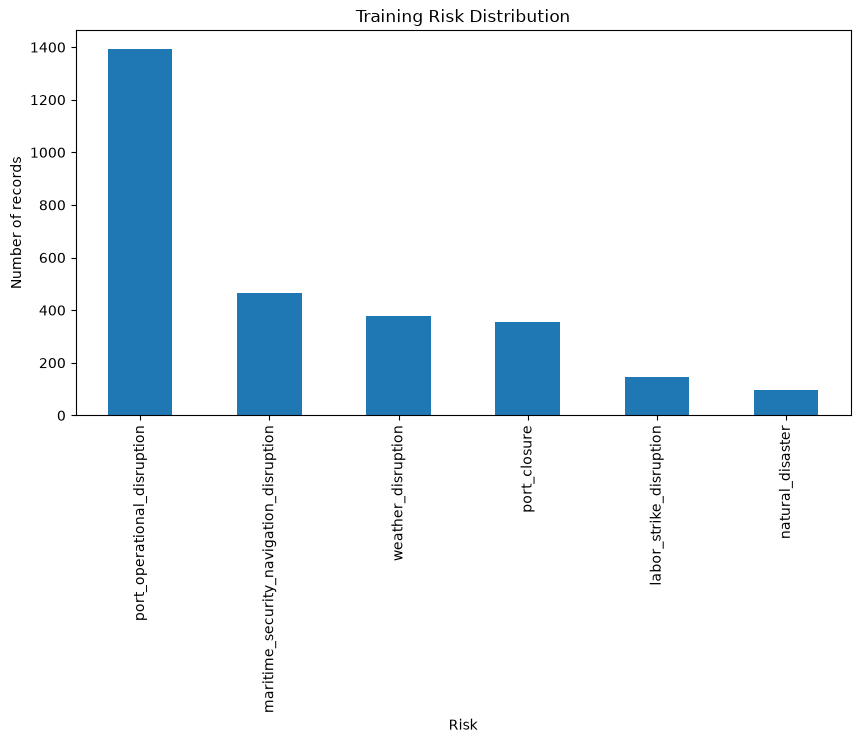

In [30]:
# count plot for class distribution 
train_label_counts.plot(
    kind="bar",
    title="Training Risk Distribution",
    figsize=(10, 5)
)

plt.ylabel("Number of records")
plt.xlabel("Risk")
plt.show()

### Text Fields

- `input_text`: Combined natural-language text from the event headline and details. It preserves the original wording and is used for semantic models, LLM input, and manual inspection.

- `normalized_text`: A lightly normalized version of `input_text`, mainly lowercased and whitespace-cleaned, used by Stage A for reliable keyword and phrase matching.

In [ ]:
# Create your classifier input text 
def prepare_text(row):
    text = row["Headline_Details"]

    if pd.isna(text):
        headline = "" if pd.isna(row["Headline"]) else str(row["Headline"])
        details = "" if pd.isna(row["Details"]) else str(row["Details"])

        text = headline + " " + details

    return str(text).strip()


In [32]:
# applying the function to the data
train_poc["input_text"] = train_poc.apply(
    prepare_text,
    axis=1
)

test_poc["input_text"] = test_poc.apply(
    prepare_text,
    axis=1
)

In [33]:
train_poc.head()

,id,Headline,Details,Severity,Region,Datetime,lat,lon,maritime_label,found_ports,...,Year,Month,Week,Details_cleaned,Category,Summarized_label,gpt-4o_label,true_risks,has_target_risk,input_text
0,552,Severe winds caused brief suspension at Port o...,Local sources reported that operations at Pier...,Minor,South Africa,2018-12-28 05:15:00,-29.88386,31.01766,true,['durban'],...,2018,12,52,local source reported operation pier 1 2 conta...,Port Disruption,Weather,{},[port_operational_disruption],True,Severe winds caused brief suspension at Port o...
1,6,UPDATE - Indonesia: Severe winds damage infras...,Severe winds have downed billboards and trees ...,Moderate,Indonesia,2017-04-19 09:10:00,-6.91264,107.657,false,['jakarta'],...,2017,4,16,severe wind downed billboard tree bandung wedn...,"Roadway Closure / Disruption, Flooding, Severe...",Weather,{},[weather_disruption],True,UPDATE - Indonesia: Severe winds damage infras...
2,4537,UPDATE 1 - Refrigerated container import capac...,Updated sources indicate that terminals at the...,Moderate,China,2020-02-03 21:57:00,38.98074,117.746,true,['tianjin'],...,2020,2,6,updated source indicate terminal tianjin port ...,"Port Disruption, Cargo Disruption, Port Conges...",Administrative Issue,{},[port_operational_disruption],True,UPDATE 1 - Refrigerated container import capac...
3,3771,Marine wind warning issued for Port of Sydney ...,Industry sources indicate that the Bureau of M...,Minor,Australia,2020-05-21 09:25:00,-33.97373,151.2168,false,['sydney'],...,2020,5,21,industry source indicate bureau meteorology is...,Weather Advisory,Weather,{},[weather_disruption],True,Marine wind warning issued for Port of Sydney ...
4,1947,Osaka’s G20 summit likely to impede logistics ...,Japan will host its first ever Group of Twenty...,Moderate,Japan,2019-06-21 15:21:00,34.43214,135.23035,false,"['kobe', 'osaka']",...,2019,6,25,japan host first ever group twenty g20 summit ...,"Cargo Disruption, Roadway Closure / Disruption...",Administrative Issue,{},"[maritime_security_navigation_disruption, port...",True,Osaka’s G20 summit likely to impede logistics ...


In [34]:
import re

def normalize_text(text):
    text = str(text).lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [35]:
train_poc["normalized_text"] = train_poc[
    "input_text"
].apply(normalize_text)

test_poc["normalized_text"] = test_poc[
    "input_text"
].apply(normalize_text)

In [36]:
train_poc[
    [
        "Headline",
        "Category",
        "true_risks",
        "normalized_text"
    ]
].sample(10, random_state=42)

,Headline,Category,true_risks,normalized_text
2470,Strong winds likely to disrupt operations at P...,Port Disruption,[port_operational_disruption],strong winds likely to disrupt operations at p...
173,Vessels’ waiting time around 12-hours at Port ...,Port Congestion,[port_operational_disruption],vessels’ waiting time around 12-hours at port ...
1229,Strike action disrupts operations at Port of L...,Port Disruption,[port_operational_disruption],strike action disrupts operations at port of l...
2140,Severe wind warning issued for coastal areas o...,Weather Advisory,[weather_disruption],severe wind warning issued for coastal areas o...
1199,Average vessel delays at Port of Tanjung Pelep...,Port Congestion,[port_operational_disruption],average vessel delays at port of tanjung pelep...
2497,"At 01:14.7N–103:57.5E, three armed robbers boa...","Ground Transportation Advisory, Maritime Advis...",[maritime_security_navigation_disruption],"at 01:14.7n–103:57.5e, three armed robbers boa..."
367,UPDATE: Average waiting times for vessels rema...,Port Congestion,[port_operational_disruption],update: average waiting times for vessels rema...
2134,Paradip Port Operations at the port have resum...,Maritime Advisory,[maritime_security_navigation_disruption],paradip port operations at the port have resum...
2341,Port of Savannah temporarily closed due to fog,Port Closure,[port_closure],port of savannah temporarily closed due to fog...
407,Port of Hong Kong’s container terminals at the...,"Port Disruption, Outbreak of disease",[port_operational_disruption],port of hong kong’s container terminals at the...


In [37]:
train_poc.head()

,id,Headline,Details,Severity,Region,Datetime,lat,lon,maritime_label,found_ports,...,Month,Week,Details_cleaned,Category,Summarized_label,gpt-4o_label,true_risks,has_target_risk,input_text,normalized_text
0,552,Severe winds caused brief suspension at Port o...,Local sources reported that operations at Pier...,Minor,South Africa,2018-12-28 05:15:00,-29.88386,31.01766,true,['durban'],...,12,52,local source reported operation pier 1 2 conta...,Port Disruption,Weather,{},[port_operational_disruption],True,Severe winds caused brief suspension at Port o...,severe winds caused brief suspension at port o...
1,6,UPDATE - Indonesia: Severe winds damage infras...,Severe winds have downed billboards and trees ...,Moderate,Indonesia,2017-04-19 09:10:00,-6.91264,107.657,false,['jakarta'],...,4,16,severe wind downed billboard tree bandung wedn...,"Roadway Closure / Disruption, Flooding, Severe...",Weather,{},[weather_disruption],True,UPDATE - Indonesia: Severe winds damage infras...,update - indonesia: severe winds damage infras...
2,4537,UPDATE 1 - Refrigerated container import capac...,Updated sources indicate that terminals at the...,Moderate,China,2020-02-03 21:57:00,38.98074,117.746,true,['tianjin'],...,2,6,updated source indicate terminal tianjin port ...,"Port Disruption, Cargo Disruption, Port Conges...",Administrative Issue,{},[port_operational_disruption],True,UPDATE 1 - Refrigerated container import capac...,update 1 - refrigerated container import capac...
3,3771,Marine wind warning issued for Port of Sydney ...,Industry sources indicate that the Bureau of M...,Minor,Australia,2020-05-21 09:25:00,-33.97373,151.2168,false,['sydney'],...,5,21,industry source indicate bureau meteorology is...,Weather Advisory,Weather,{},[weather_disruption],True,Marine wind warning issued for Port of Sydney ...,marine wind warning issued for port of sydney ...
4,1947,Osaka’s G20 summit likely to impede logistics ...,Japan will host its first ever Group of Twenty...,Moderate,Japan,2019-06-21 15:21:00,34.43214,135.23035,false,"['kobe', 'osaka']",...,6,25,japan host first ever group twenty g20 summit ...,"Cargo Disruption, Roadway Closure / Disruption...",Administrative Issue,{},"[maritime_security_navigation_disruption, port...",True,Osaka’s G20 summit likely to impede logistics ...,osaka’s g20 summit likely to impede logistics ...


In [38]:
columns_to_keep = [
    "id",
    "Headline",
    "Details",
    "Severity",
    "Region",
    "Datetime",
    "lat",
    "lon",
    "maritime_label",
    "found_ports",
    "contains_port_info",
    "Category",
    "Summarized_label",
    "true_risks",
    "input_text",
    "normalized_text"
]

train_poc = train_poc[columns_to_keep].copy()
test_poc = test_poc[columns_to_keep].copy()

In [39]:
from pathlib import Path

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

train_poc.to_csv(DATA_DIR / "train_poc.csv", index=False)
test_poc.to_csv(DATA_DIR / "test_poc.csv", index=False)